In [14]:
import pandas as pd
import re

df = pd.read_csv('/Users/alokmalla/Documents/Applied_ML/PROJECT/full_data.csv', encoding='utf-8')



df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [15]:
df_true_tmp = df[df['label'] == 1]
df_false_tmp = df[df['label'] == 0]


percentage_true = len(df_true_tmp) / len(df) * 100
print(f"Percentage of true labels: {percentage_true:.2f}%")

Percentage of true labels: 51.44%


In [16]:
df.shape

(72134, 4)

## NULL statstics

In [ ]:

null_row_percentage = df.isnull().any(axis=1).mean() * 100
print(df.isnull().any(axis=1).sum(), "rows with at least one NULL entry")
print(f"Percentage of rows with at least one NULL entry: {null_row_percentage:.2f}%")

597 rows with at least one NULL entry
Percentage of rows with at least one NULL entry: 0.83%


In [ ]:

duplicate_text_percentage = df.duplicated(subset=['text']).mean() * 100
print(df.duplicated(subset=['text']).sum())
print(f"Percentage of duplicate 'text' entries: {duplicate_text_percentage:.2f}%")

9415
Percentage of duplicate 'text' entries: 13.05%


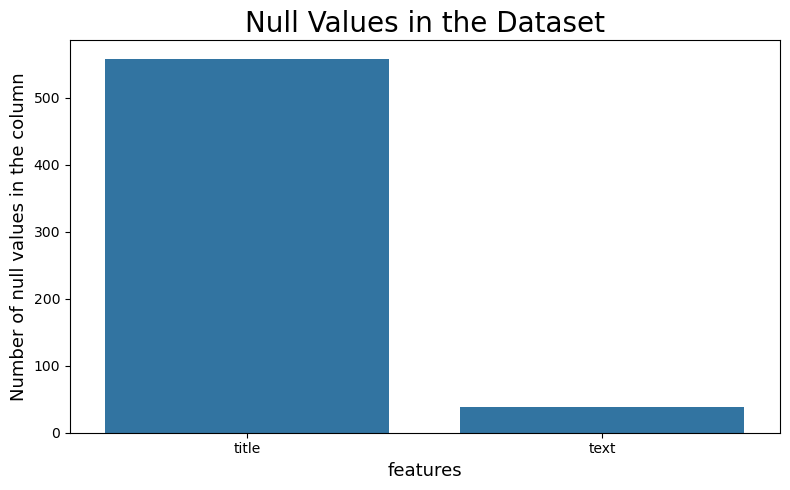

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_nulls(data, title, x_axis_label, y_axis_label):

    data_nulls = data.isnull().sum().reset_index()
    data_nulls.columns = ['feature', 'null_count']
    plt.figure(figsize=(8, 5))
    sns.barplot(data=data_nulls, x="feature", y="null_count")
    plt.title(title, fontsize=20)
    plt.xlabel(x_axis_label, fontsize=13)
    plt.ylabel(y_axis_label, fontsize=13)
    plt.tight_layout()
    plt.savefig('./img/nulls_plot_sum.png')
    plt.show()

plot_nulls(
    df.copy().drop(['Unnamed: 0', 'label'], axis=1),
    "Null Values in the Dataset",
    'features',
    'Number of null values in the column'
)


In [20]:
df[df['label'] == 0].isna().sum()



Unnamed: 0    0
title         0
text          0
label         0
dtype: int64

In [21]:
nulls_by_label = df.groupby('label').apply(lambda x: x.isnull().mean() * 100).T

/var/folders/g9/r4_g7mt93vbckqrjs6znjvf80000gn/T/ipykernel_43517/3201190447.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nulls_by_label = df.groupby('label').apply(lambda x: x.isnull().mean() * 100).T


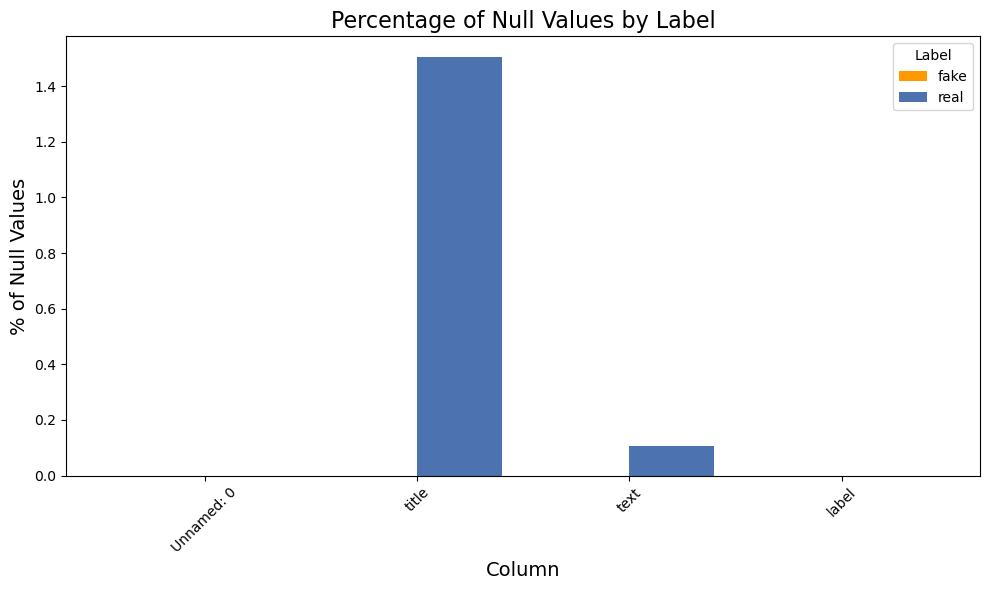

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt



custom_colors = ['#FF9900', '#4C72B0']

ax = nulls_by_label.plot(
    kind='bar',
    width=0.8,
    color=custom_colors,
    figsize=(10, 6)
)
plt.title('Percentage of Null Values by Label', fontsize=16)
plt.xlabel('Column', fontsize=14)
plt.ylabel('% of Null Values', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Label', labels=['fake', 'real'])
plt.tight_layout()
plt.savefig('./img/nulls_by_label.png')
plt.show()


## DATA DISTRIBUTION

/var/folders/g9/r4_g7mt93vbckqrjs6znjvf80000gn/T/ipykernel_43517/1610850903.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


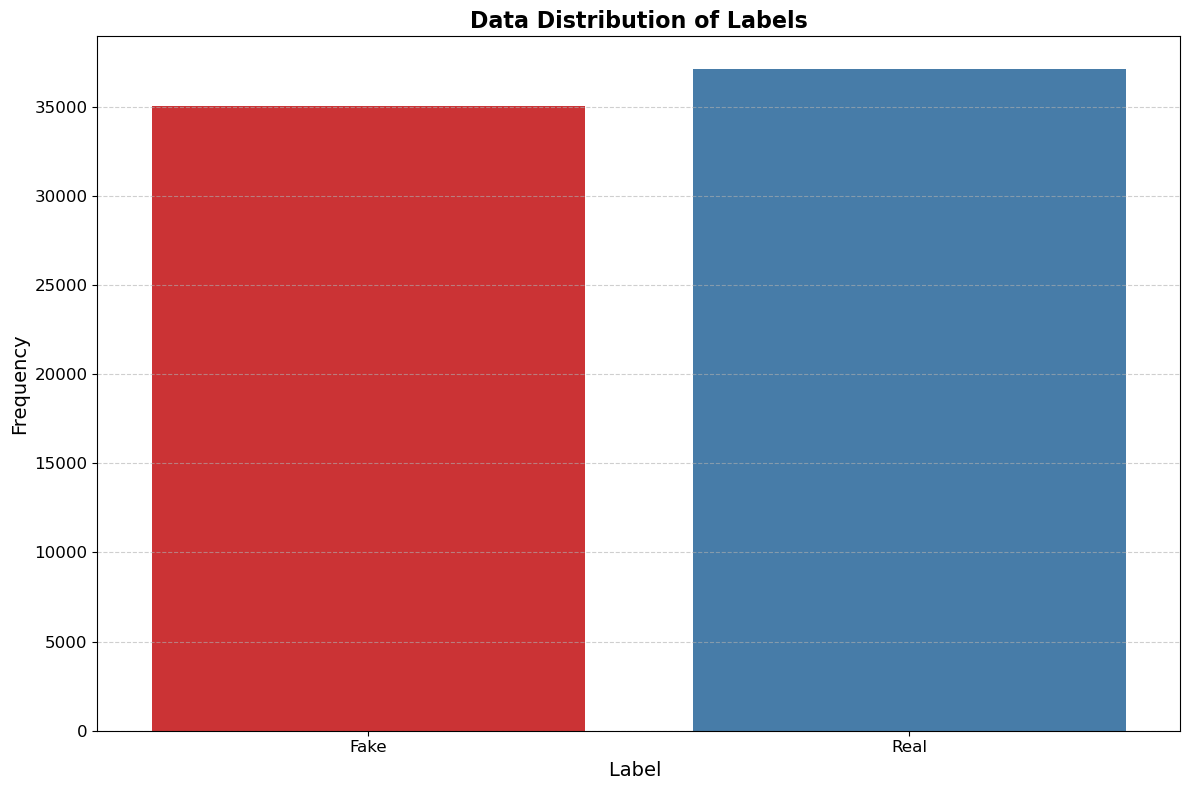

In [23]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.countplot(
    data=df,
    x='label',
    palette='Set1',
)
plt.title('Data Distribution of Labels', fontsize=16, fontweight='bold')
plt.xlabel('Label ', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks([0, 1], ['Fake', 'Real'], fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6, axis='y')
plt.tight_layout()
plt.savefig('./img/dataDistribution')
plt.show()


## TEXT lenght analysis

In [24]:
len_data_df = df.copy()[['text', 'label']]

len_data_df['text length'] = len_data_df['text'].fillna('').apply(len)

len_data_df['text length'].describe()

len_data_df.head()


,text,label,text length
0,No comment is expected from Barack Obama Membe...,1,5049
1,Did they post their votes for Hillary already?,1,46
2,"Now, most of the demonstrators gathered last ...",1,216
3,A dozen politically active pastors came here f...,0,8010
4,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,1916


In [25]:
len_data_df['text length'].describe()

count     72134.000000
mean       3268.387834
std        3732.877545
min           0.000000
25%        1377.000000
50%        2424.000000
75%        4059.000000
max      142961.000000
Name: text length, dtype: float64

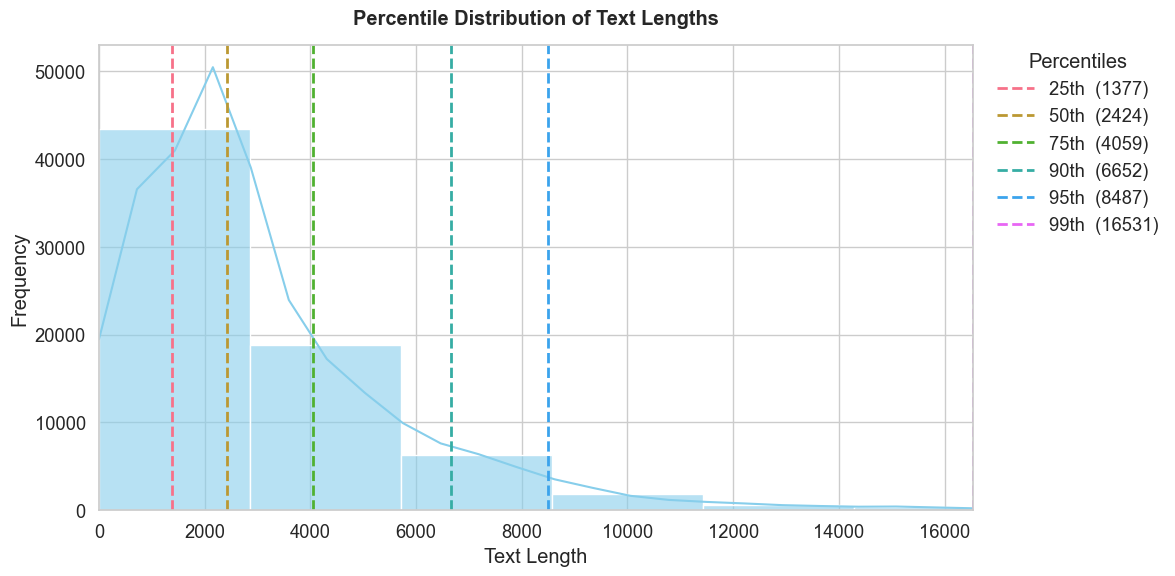

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set1", font_scale=1.2)
plt.figure(figsize=(12, 6))

xmax = len_data_df['text length'].quantile(0.99)

ax = sns.histplot(
    len_data_df['text length'],
    bins=50,
    kde=True,
    color="skyblue",
    edgecolor="white",
    alpha=0.6
)


ax.set_xlim(0, xmax)

percentiles = [25, 50, 75, 90, 95, 99]
palette = sns.color_palette("husl", len(percentiles))  
lines, labels = [], []

for pct, col in zip(percentiles, palette):
    v = len_data_df['text length'].quantile(pct/100)
    ln = ax.axvline(v, color=col, linestyle="--", linewidth=2)
    lines.append(ln)
    labels.append(f"{pct}th  ({int(v)})")

ax.legend(
    lines,
    labels,
    title="Percentiles",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    frameon=False
)

ax.set_title("Percentile Distribution of Text Lengths", fontweight="bold", pad=15)
ax.set_xlabel("Text Length")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.savefig('./img/text_length_distribution.png')   
plt.show()


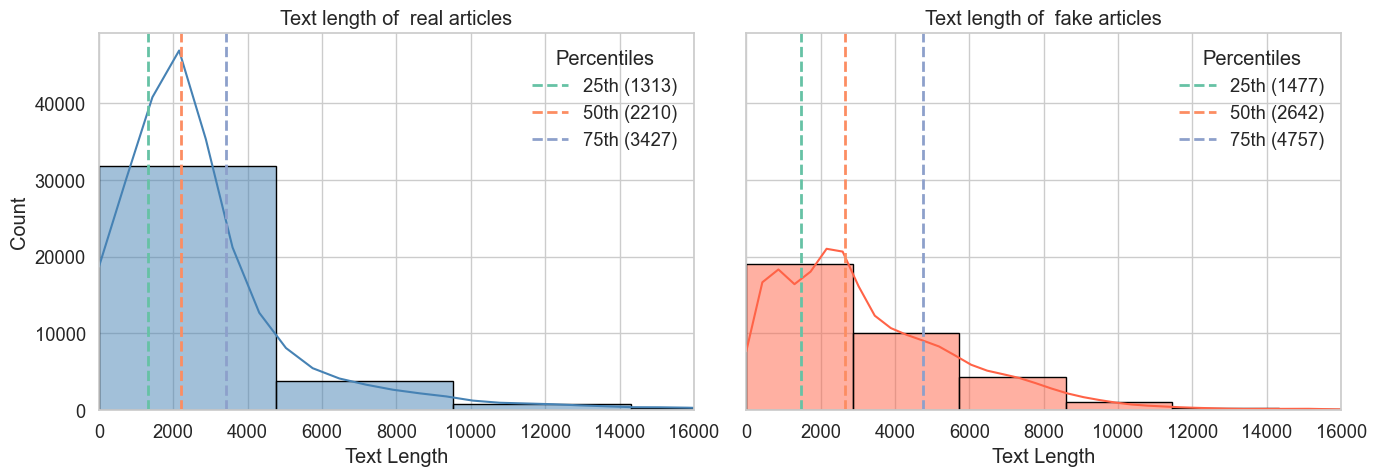

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.2)
labels = len_data_df['label'].unique()
fig, axes = plt.subplots(1, len(labels), figsize=(7 * len(labels), 5), sharey=True)
if len(labels) == 1:
    axes = [axes]

fake_mapping = {1: "real", 0: "fake"}
color_mapping = {1: "steelblue", 0: "tomato"}
percentiles = [25, 50, 75]
palette = sns.color_palette("Set2", len(percentiles))

for ax, label in zip(axes, labels):
    subset = len_data_df[len_data_df['label'] == label]
    sns.histplot(
        subset['text length'],
        bins=30,
        kde=True,
        ax=ax,
        color=color_mapping[label],
        edgecolor='black'
    )
    lines = []
    labels_ = []
    for pct, col in zip(percentiles, palette):
        v = subset['text length'].quantile(pct/100)
        ln = ax.axvline(v, color=col, linestyle="--", linewidth=2)
        lines.append(ln)
        labels_.append(f"{pct}th ({int(v)})")
    ax.legend(lines, labels_, title="Percentiles", loc="upper right", frameon=False)
    ax.set_title(f"Text length of  {fake_mapping[label]} articles")
    ax.set_xlabel("Text Length")
    ax.set_ylabel("Count")
    ax.set_xlim(0, 16000)

plt.tight_layout()
plt.show()


## Text word analysis

In [28]:
texts = df[df['label'] == 0]['text'].fillna('')
all_words = " ".join(texts)



In [29]:
texts.shape

(35028,)

In [ ]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_fillers(text: str) -> str:
    """
    Remove common English filler words (stop words) and words shorter than 3 characters from a string.
    Uses scikit-learn’s built-in ENGLISH_STOP_WORDS set.
    """
    
    words = re.findall(r'\b\w+\b', text.lower())
    
    filtered = [w for w in words if w not in ENGLISH_STOP_WORDS and len(w) >= 3]
    
    return " ".join(filtered)


all_words = remove_fillers(all_words)




In [31]:
unique_words = set(all_words.split())
print(f"Number of unique words in all_words: {len(unique_words)}")

Number of unique words in all_words: 124566


In [ ]:
# import spacy

# # load English model (make sure you've run: python -m spacy download en_core_web_sm)
# nlp = spacy.load("en_core_web_sm")
# nlp.max_length = max(nlp.max_length, 2 * len(all_words))

# def remove_verbs(text: str) -> str:
#     """
#     Remove all verbs (and auxiliaries) from the input text.
#     """
#     doc = nlp(text)
#     # keep tokens whose coarse POS tag is not VERB or AUX
#     filtered = [token.text for token in doc if token.pos_ not in {"VERB", "AUX"}]
#     return " ".join(filtered)

# # Example
# all_words = remove_verbs(all_words)

# # -> "This the test all and filler words from it , also strip !"


In [ ]:
import re
from collections import Counter

def top_n_words(text, n=5):
    
    words = re.findall(r'\b\w+\b', text.lower())
   
    return Counter(words).most_common(n)






In [ ]:
tmp_df = pd.read_csv('./csvs/words_analysis.csv')

tmp_df.head()

In [ ]:
top_20_words = top_n_words(all_words, 20)
print(top_20_words)

In [ ]:
import pandas as pd

tmp_df = pd.read_csv('./csvs/words_analysis.csv')

top_20_words = top_n_words(all_words, 20)



new_tmp_df = pd.DataFrame({
    'fake_words': [x for x,y in top_20_words],
    'real_frequency_words': [y for x,y in top_20_words]
})


df_updated = pd.concat([tmp_df, new_tmp_df], axis=1)
# Save the updated DataFrame back to CSV
df_updated.to_csv('./csvs/words_analysis.csv', index=False)




In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

words, counts = zip(*top_50_words)
plt.figure(figsize=(14, 6))
sns.barplot(x=list(words), y=list(counts), palette="pastel")
plt.xticks(rotation=75)
plt.title("Top 30 Most Frequent Words (after stopword removal)", fontsize=16, fontweight='bold')
plt.xlabel("Word", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import random


def red_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return "hsl({}, {}%, {}%)".format(
        random.randint(100, 140),  
        random.randint(50, 120),  # Saturation
        random.randint(30, 80)    # Lightness
    )

titles = all_words
wordcloud = WordCloud(
    background_color='white', 
    max_words=300,
    width=800, 
    height=400,
    color_func=red_color_func  # Apply the red tone color function
).generate(titles)

plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.savefig('./img/real_frequentWords_text')
plt.show()


## find most frequent word pairs


In [ ]:
from collections import Counter

def top_n_bigrams(text, n=10):
    words = re.findall(r'\b\w+\b', text.lower())
    bigrams = zip(words, words[1:])
    bigram_counts = Counter([" ".join(b) for b in bigrams])
    return bigram_counts.most_common(n)


top_20_bigrams = top_n_bigrams(all_words, 20)
print(top_20_bigrams)


In [ ]:
import seaborn as sns

import matplotlib.pyplot as plt

bigrams, counts = zip(*top_20_bigrams)
plt.figure(figsize=(14, 6))
sns.barplot(x=list(bigrams), y=list(counts), palette="pastel")
plt.xticks(rotation=75)
plt.title("Top 20 Most Frequent Bigrams (after stopword removal)", fontsize=16, fontweight='bold')
plt.xlabel("Bigram", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.tight_layout()
plt.savefig('./img/top_20_real_bigrams')
plt.show()

In [ ]:
import pandas as pd


df_existing = pd.read_csv('./csvs/bigrams_analysis.csv')


new_columns_df = pd.DataFrame({
    'fake_frequency_bigram': bigrams,
    'fake_frequency_bingram': counts
})


df_updated = pd.concat([df_existing, new_columns_df], axis=1)


df_updated.to_csv('./csvs/bigrams_analysis.csv', index=False)


## fake real words anaylsis

### bigrams

In [4]:
import pandas as pd 
df_bi = pd.read_csv('./csvs/bigrams_analysis.csv' )

df_bi.head()

,real_bigram,real_frequency_bigram,fake_bigram,fake_frequency_bigram
0,donald trump,23102,united states,22262
1,hillary clinton,16618,donald trump,16902
2,united states,12079,white house,14005
3,white house,9646,new york,12837
4,featured image,7928,president donald,7111


In [5]:
fake_pairs = set(df_bi['fake_bigram'])

real_pairs = set(df_bi['real_bigram'])




In [6]:
fake_but_notReal = fake_pairs - real_pairs
real_but_notFake = real_pairs - fake_pairs

print(f"fake: {fake_but_notReal}")

print(f"real: {real_but_notFake}")



fake: {'mrs clinton', 'trump said', 'president donald', 'washington reuters', 'prime minister', 'said statement', 'supreme court', 'islamic state', 'national security', 'north korea', 'president barack', 'told reporters', 'trump administration'}
real: {'fox news', 'pic twitter', 'obama administration', 'getty images', 'twitter com', 'american people', 'featured image', 'october 2016', 'president trump', 'clinton campaign', 'year old', 'president obama', 'law enforcement'}


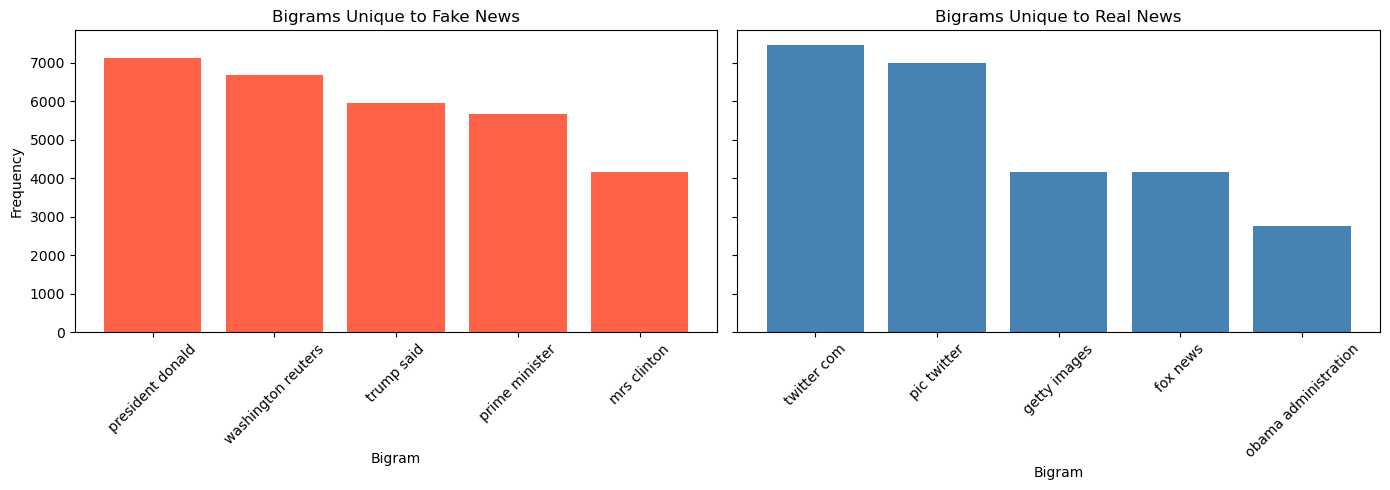

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter


fake_freqs_plot = [df_bi.loc[df_bi['fake_bigram'] == bigram, 'fake_frequency_bigram'].values[0] for bigram in fake_but_notReal] [:5]
fake_sorted = sorted(zip(fake_but_notReal, fake_freqs_plot), key=lambda x: x[1], reverse=True)
fake_bigrams_sorted, fake_freqs_sorted = zip(*fake_sorted)


real_freqs_plot = [df_bi.loc[df_bi['real_bigram'] == bigram, 'real_frequency_bigram'].values[0] for bigram in real_but_notFake][:5]
real_sorted = sorted(zip(real_but_notFake, real_freqs_plot), key=lambda x: x[1], reverse=True)
real_bigrams_sorted, real_freqs_sorted = zip(*real_sorted)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)


axes[0].bar(fake_bigrams_sorted, fake_freqs_sorted, color='tomato')
axes[0].set_title('Bigrams Unique to Fake News')
axes[0].set_xlabel('Bigram')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=45)


axes[1].bar(real_bigrams_sorted, real_freqs_sorted, color='steelblue')
axes[1].set_title('Bigrams Unique to Real News')
axes[1].set_xlabel('Bigram')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('./img/unique_bigrams_frequency_byLabel.png')
plt.show()


### single words

In [ ]:
import numpy as np

import pandas as pd

df_si = pd.read_csv('./csvs/words_analysis.csv' )

df_si.head()

,real_words,real_frequency_words,fake_words,real_frequency_words.1
0,trump,106364,said,184607
1,said,49712,trump,107201
2,people,48653,president,51300
3,clinton,45411,new,42528
4,president,38982,people,41792


In [8]:
fake_sin = set(df_si['fake_words'])

real_sin = set(df_si['real_words'])


In [9]:
fake_but_notReal_si = fake_sin - real_sin
real_but_notFake_si = real_sin - fake_sin

print(f"fake: {fake_but_notReal_si}")

print(f"real: {real_but_notFake_si}")


fake: {'republican', 'house', 'united', 'year', 'reuters', 'told', 'party', 'campaign', 'states'}
real: {'election', 'world', 'american', 'hillary', 'just', 'white', 'news', 'donald', 'media'}


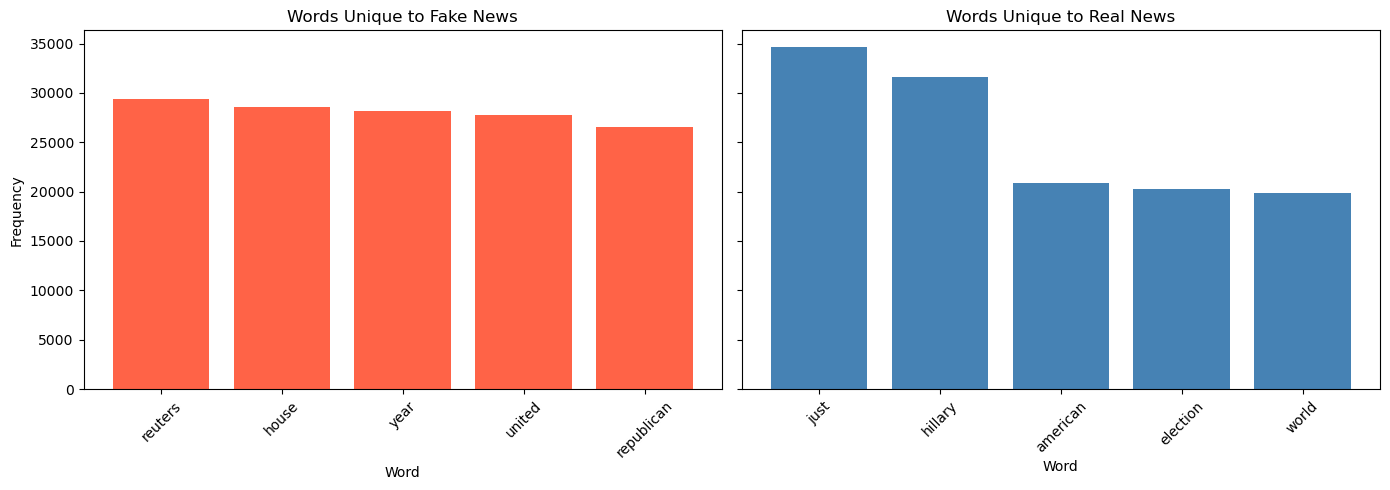

In [ ]:
import matplotlib.pyplot as plt


fake_freqs_plot = [df_si.loc[df_si['fake_words'] == word, 'real_frequency_words.1'].values[0] for word in fake_but_notReal_si][:5]

fake_sorted = sorted(zip(fake_but_notReal_si, fake_freqs_plot), key=lambda x: x[1], reverse=True)
fake_words_sorted, fake_freqs_sorted = zip(*fake_sorted)


real_freqs_plot = [df_si.loc[df_si['real_words'] == word, 'real_frequency_words'].values[0] for word in real_but_notFake_si] [:5]

real_sorted = sorted(zip(real_but_notFake_si, real_freqs_plot), key=lambda x: x[1], reverse=True)
real_words_sorted, real_freqs_sorted = zip(*real_sorted)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)


axes[0].bar(fake_words_sorted, fake_freqs_sorted, color='tomato')
axes[0].set_title('Words Unique to Fake News')
axes[0].set_xlabel('Word')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=45)


axes[1].bar(real_words_sorted, real_freqs_sorted, color='steelblue')
axes[1].set_title('Words Unique to Real News')
axes[1].set_xlabel('Word')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('./img/unique_words_frequency_byLabel.png')
plt.show()


## TITLE: Text word analysis


In [ ]:
title_df = df[['title','label']].copy()
title_df['title'] = title_df['title'].fillna('')

title_df['title length'] = title_df['title'].apply(lambda x: len(x))

title_df.head()



In [ ]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_fillers(text: str) -> str:
    """
    Remove common English filler words (stop words) and words shorter than 3 characters from a string.
    Uses scikit-learn’s built-in ENGLISH_STOP_WORDS set.
    """
    
    words = re.findall(r'\b\w+\b', text.lower())
    
    filtered = [w for w in words if w not in ENGLISH_STOP_WORDS and len(w) >= 3]
    
    return " ".join(filtered)


all_words = remove_fillers(all_words)




## Title classifier